# **LO1 – Visualization basics & chart types**

In [16]:
# === LO1: Visualization Fundamentals ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load data from GitHub ---
base_url = "https://raw.githubusercontent.com/rodrigourech/gdv/main/"
tas45 = pd.read_csv(base_url + "RCP45_tas.csv")
tas85 = pd.read_csv(base_url + "RCP85_tas.csv")
tas = pd.concat([tas45, tas85], ignore_index=True)

# --- Preprocess ---
tas["scenario"] = tas["scenario"].astype("category")
tas["date"] = pd.to_datetime(tas["date"])
tas["year"] = tas["date"].dt.year
tas["month"] = tas["date"].dt.month
tas["doy"] = tas["date"].dt.dayofyear
tas["decade"] = (tas["year"] // 10) * 10

# --- Subsets ---
stations = ["Zürich", "Lugano", "Davos"]
tas_s = tas[tas["station"].isin(stations)].copy()
tas85_zurich = tas[(tas["station"] == "Zürich") & (tas["scenario"] == "RCP85")].copy()


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_33204\3997686285.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ann = tas.groupby(["scenario", "year"], as_index=False)["value"].mean()


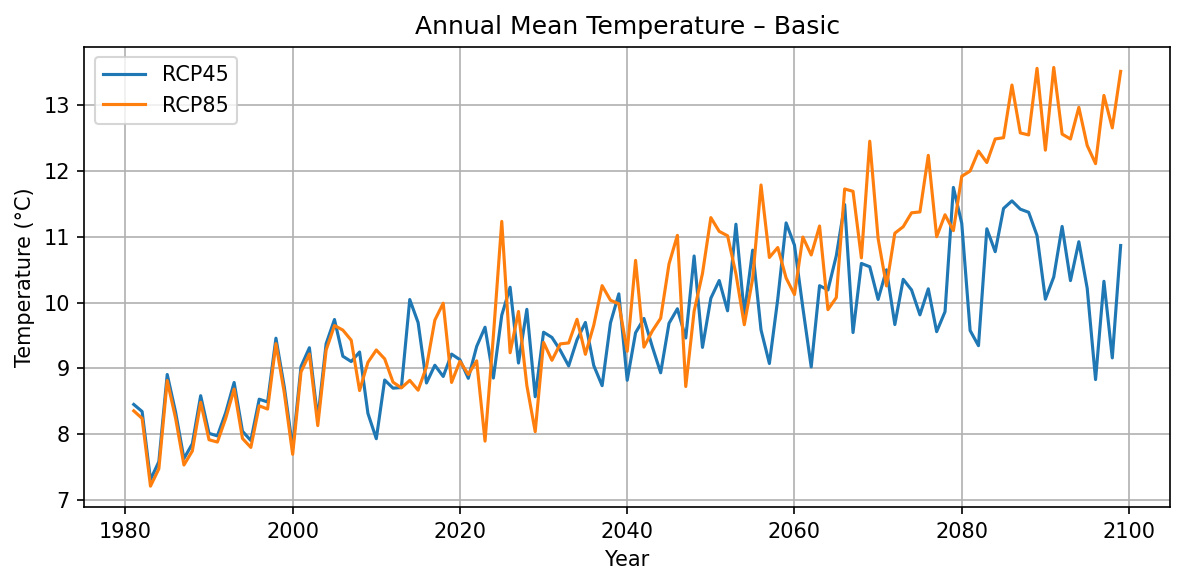

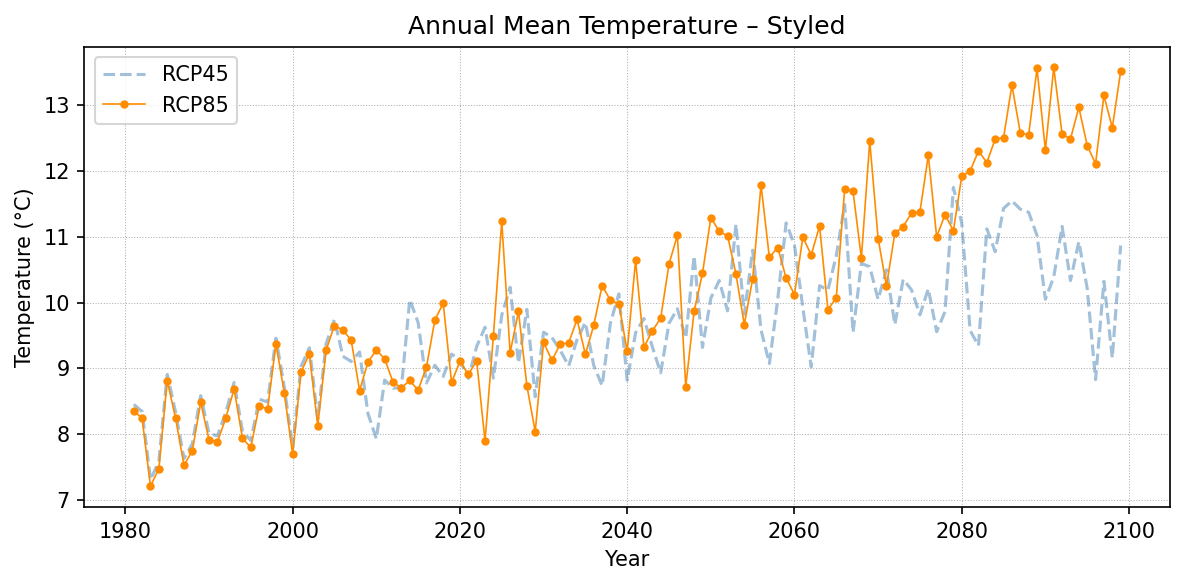

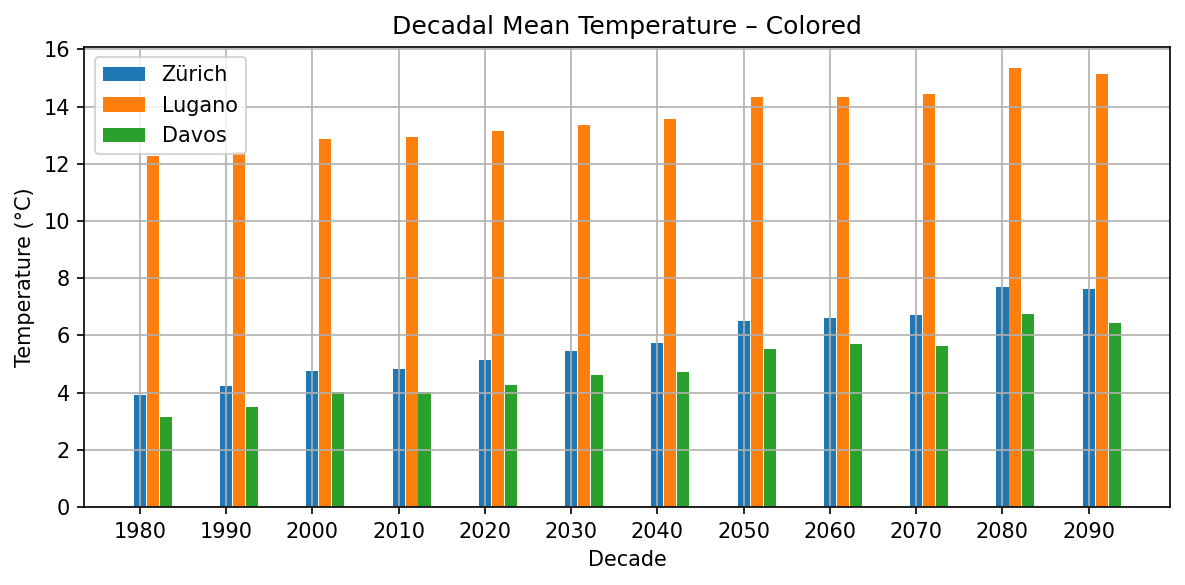

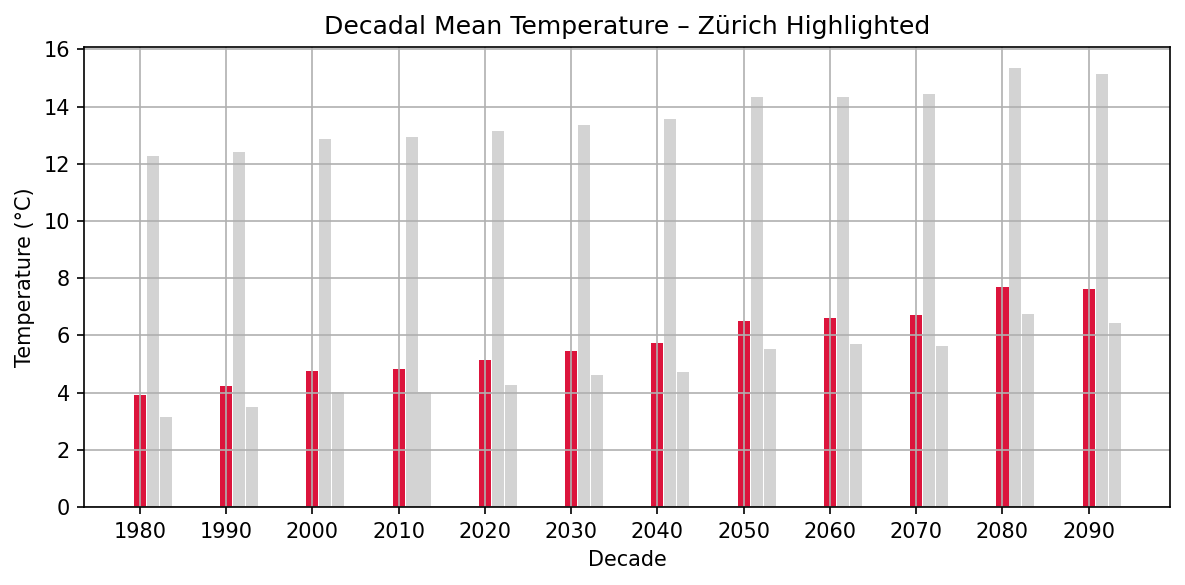

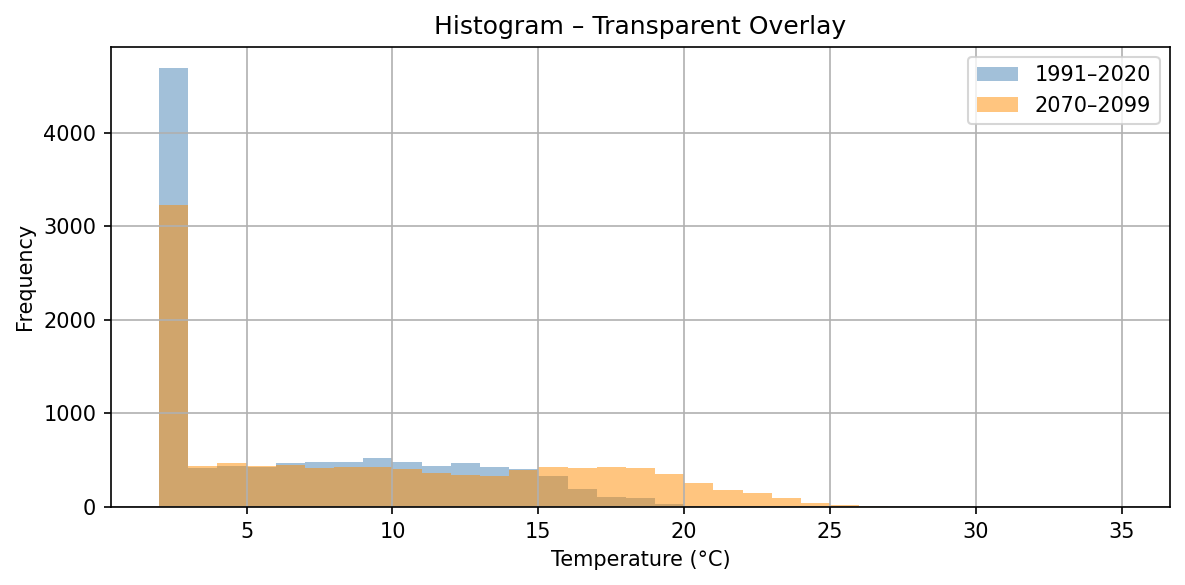

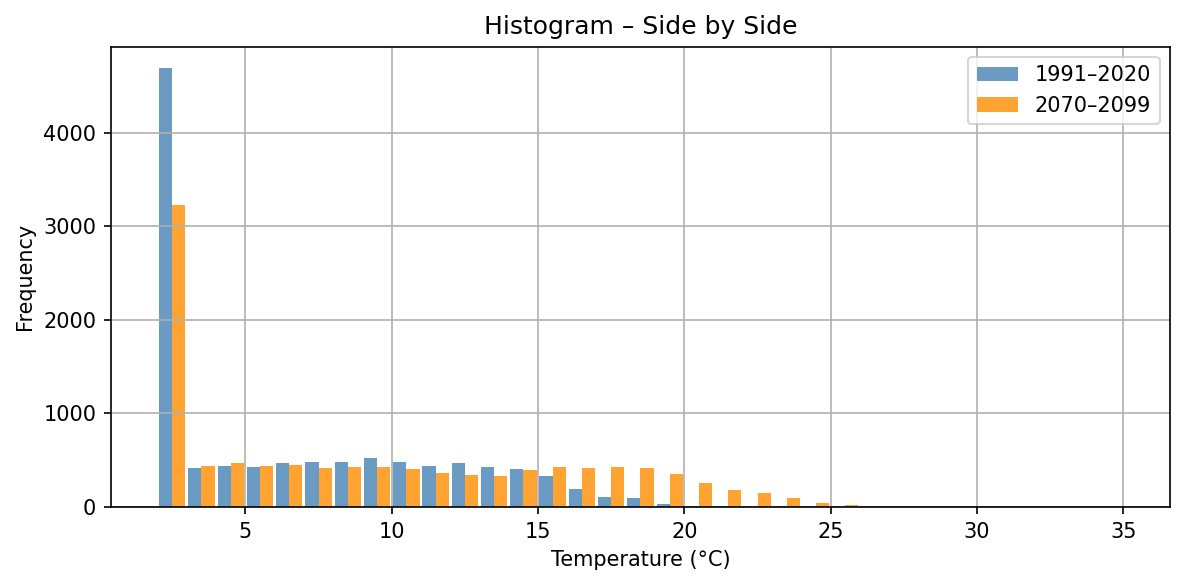

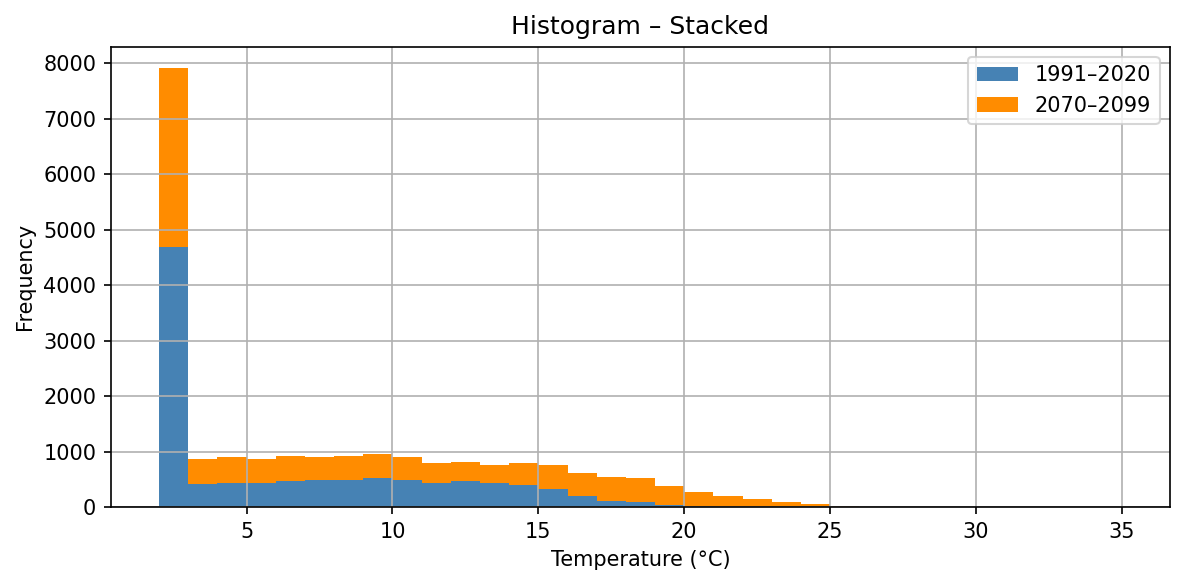

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_33204\3997686285.py:111: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  mat = mat.rolling(3, axis=1, min_periods=1).mean()


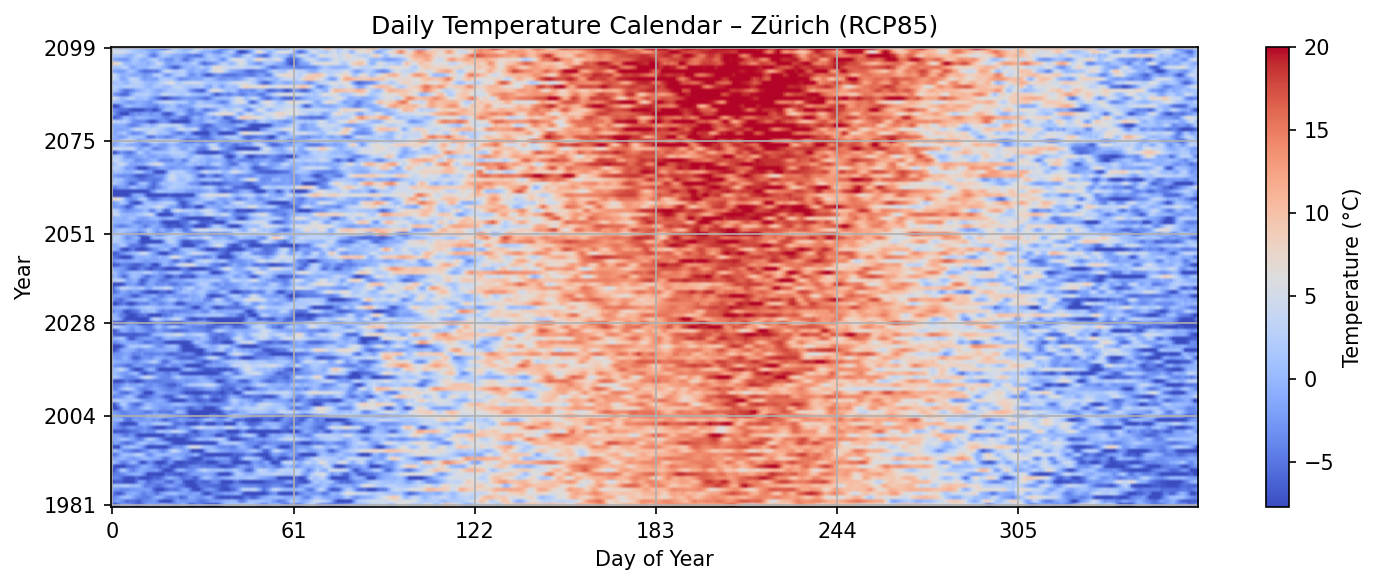

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_33204\3997686285.py:133: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  mat = mat.rolling(3, axis=1, min_periods=1).mean()


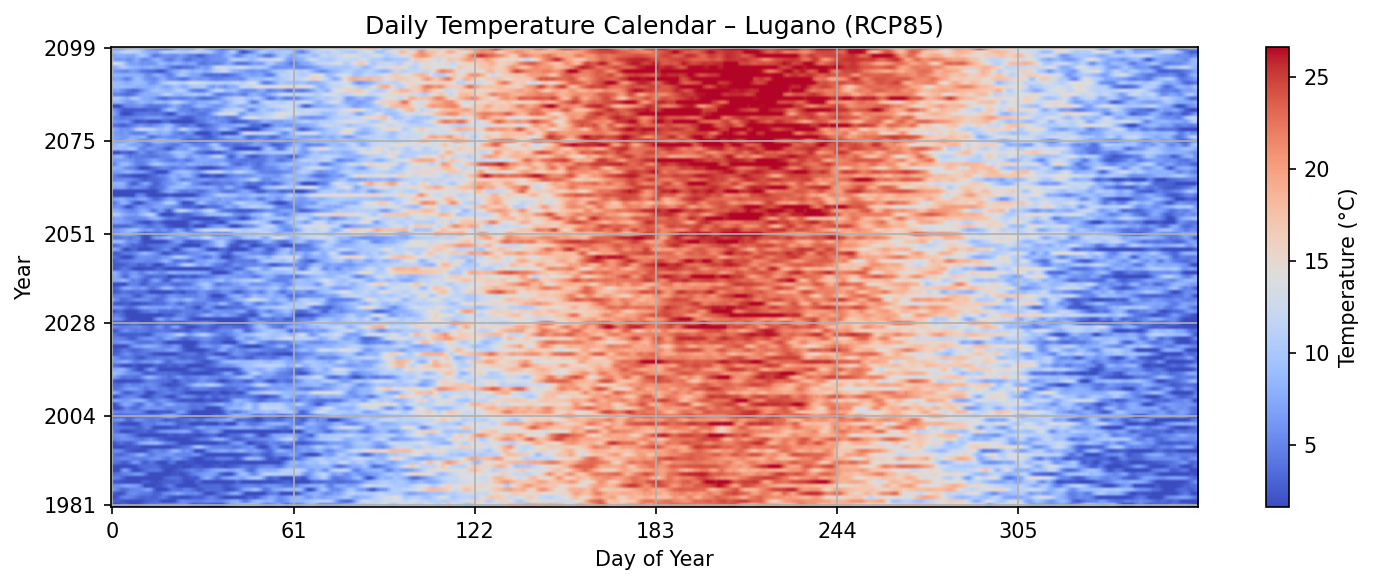

In [23]:
# --- Plot 1a: Basic line chart (RCP45 vs RCP85) ---
ann = tas.groupby(["scenario", "year"], as_index=False)["value"].mean()
ann = ann.rename(columns={"value": "tas_ann_mean"})

fig, ax = plt.subplots(figsize=(8, 4))
for scen in ["RCP45", "RCP85"]:
    data = ann[ann["scenario"] == scen]
    ax.plot(data["year"], data["tas_ann_mean"], label=scen)
ax.set_title("Annual Mean Temperature – Basic")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()
fig.tight_layout()
plt.show()

# --- Plot 1b: Styled line chart (RCP85 highlighted) ---
fig, ax = plt.subplots(figsize=(8, 4))
for scen in ["RCP45", "RCP85"]:
    data = ann[ann["scenario"] == scen]
    if scen == "RCP85":
        ax.plot(data["year"], data["tas_ann_mean"], label="RCP85", color="darkorange", linewidth=0.8, marker=".")
    else:
        ax.plot(data["year"], data["tas_ann_mean"], label="RCP45", color="steelblue", linestyle="--", alpha=0.5)
ax.set_title("Annual Mean Temperature – Styled")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.5)
fig.tight_layout()
plt.show()

# --- Plot 2a: Decadal barplot by station (colored) ---
decadal = tas_s.groupby(["station", "decade"], as_index=False)["value"].mean()
decadal = decadal.rename(columns={"value": "tas_dec_mean"})

fig, ax = plt.subplots(figsize=(8, 4))
for i, station in enumerate(stations):
    data = decadal[decadal["station"] == station]
    ax.bar(data["decade"] + i * 1.5, data["tas_dec_mean"], width=1.4, label=station)
ax.set_title("Decadal Mean Temperature – Colored")
ax.set_xlabel("Decade")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(decadal["decade"].unique())
ax.legend()
fig.tight_layout()
plt.show()


# --- Plot 2c: Zürich highlighted ---
fig, ax = plt.subplots(figsize=(8, 4))
for i, station in enumerate(stations):
    data = decadal[decadal["station"] == station]
    color = "crimson" if station == "Zürich" else "lightgrey"
    ax.bar(data["decade"] + i * 1.5, data["tas_dec_mean"], width=1.4, color=color)
ax.set_title("Decadal Mean Temperature – Zürich Highlighted")
ax.set_xlabel("Decade")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(decadal["decade"].unique())
fig.tight_layout()
plt.show()

# --- Plot 3a: Histogram – Transparent Overlay ---
BASELINE_YEARS = (1991, 2020)
FUTURE_YEARS = (2070, 2099)
y0, y1 = BASELINE_YEARS
f0, f1 = FUTURE_YEARS

base_vals = tas85_zurich[(tas85_zurich["year"] >= y0) & (tas85_zurich["year"] <= y1)]["value"].clip(2, 35)
fut_vals = tas85_zurich[(tas85_zurich["year"] >= f0) & (tas85_zurich["year"] <= f1)]["value"].clip(2, 35)
bins = np.arange(2, 36, 1)

plt.figure(figsize=(8, 4))
plt.hist(base_vals, bins=bins, color="steelblue", alpha=0.5, label=f"{y0}–{y1}")
plt.hist(fut_vals, bins=bins, color="darkorange", alpha=0.5, label=f"{f0}–{f1}")
plt.title("Histogram – Transparent Overlay")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3b: Histogram – Side by Side ---
base_counts, _ = np.histogram(base_vals, bins=bins)
fut_counts, _ = np.histogram(fut_vals, bins=bins)
width = 0.9 * (bins[1] - bins[0]) / 2
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8, 4))
plt.bar(bin_centers - width / 2, base_counts, width=width, color="steelblue", alpha=0.8, label=f"{y0}–{y1}")
plt.bar(bin_centers + width / 2, fut_counts, width=width, color="darkorange", alpha=0.8, label=f"{f0}–{f1}")
plt.title("Histogram – Side by Side")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3c: Histogram – Stacked ---
plt.figure(figsize=(8, 4))
plt.hist([base_vals, fut_vals], bins=bins, stacked=True,
         color=["steelblue", "darkorange"], label=[f"{y0}–{y1}", f"{f0}–{f1}"])
plt.title("Histogram – Stacked")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 4a: Calendar Heatmap Zürich ---
mat = tas85_zurich.pivot_table(index="year", columns="doy", values="value", aggfunc="mean")
mat = mat.rolling(3, axis=1, min_periods=1).mean()
vmin, vmax = np.nanpercentile(mat.values, [2, 98])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(mat.values, aspect="auto", origin="lower", vmin=vmin, vmax=vmax, cmap="coolwarm")
ax.set_title("Daily Temperature Calendar – Zürich (RCP85)")
ax.set_xlabel("Day of Year")
ax.set_ylabel("Year")
yticks = np.linspace(0, len(mat.index) - 1, 6, dtype=int)
ax.set_yticks(yticks)
ax.set_yticklabels(mat.index.values[yticks])
xticks = np.arange(0, 366, 61)
ax.set_xticks(xticks)
ax.set_xticklabels([str(int(x)) for x in xticks])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Temperature (°C)")
fig.tight_layout()
plt.show()

# --- Plot 4b: Calendar Heatmap Lugano ---
tas85_lugano = tas[(tas["station"] == "Lugano") & (tas["scenario"] == "RCP85")].copy()
mat = tas85_lugano.pivot_table(index="year", columns="doy", values="value", aggfunc="mean")
mat = mat.rolling(3, axis=1, min_periods=1).mean()
vmin, vmax = np.nanpercentile(mat.values, [2, 98])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(mat.values, aspect="auto", origin="lower", vmin=vmin, vmax=vmax, cmap="coolwarm")
ax.set_title("Daily Temperature Calendar – Lugano (RCP85)")
ax.set_xlabel("Day of Year")
ax.set_ylabel("Year")
yticks = np.linspace(0, len(mat.index) - 1, 6, dtype=int)
ax.set_yticks(yticks)
ax.set_yticklabels(mat.index.values[yticks])
xticks = np.arange(0, 366, 61)
ax.set_xticks(xticks)
ax.set_xticklabels([str(int(x)) for x in xticks])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Temperature (°C)")
fig.tight_layout()
plt.show()
